# 06 – Conformal Anomaly Detection: Variants A and B 

**Answers sub-question 2**: *How can a conformal anomaly detector be constructed from these features, and how does the choice of nonconformity measure affect detection performance and the validity of the calibrated false-alarm guarantee?*

## Two variants compared

**Variant A – feature-based inductive conformal prediction.**
- Each row (trajectory point) is scored. Per-point detection.
- The nonconformity score is a k-NN distance in the feature space (top discriminating features from notebook 04).
- The model is fit on rule-normal training rows to genuinely 'learn normal'.
- Calibration set produces the empirical distribution of nonconformity scores; the (1−ε) quantile defines the threshold.

**Variant B – SHNN-CAD on resampled trajectories.**
- Each *trajectory* is scored as a whole (and at each prefix length, for the per-point view).
- The nonconformity score is the directed Hausdorff distance to the k-th nearest training trajectory, evaluated on arc-length-resampled (X, Y) sequences.

## Why both

A and B capture different anomaly types. A flags single-frame events (a sudden brake, an isolated low-speed point in the zone). B flags whole-path anomalies (a trajectory that took an unusual route). For the thesis, evaluating both allows for a better comparison against the rule labels, and about the trade-off between per-frame responsiveness (A) and whole-event recognition (B).

## What is held fixed across the two

- The same train/cal/test split (notebook 05).
- The same rule-based labels for evaluation (notebook 03).
- The same set of significance levels ε ∈ {0.5%, 1%, 2%, 5%, 10%}.
- The same evaluation metrics: empirical false-alarm rate, precision/recall against `rule_any`, and per-point flag rate.

#### Caveat carried over from notebook 05

The `deviation_m` feature was computed in notebook 02 using cluster medians built from all vehicles. Strictly leak-free practice would re-fit those medians on training data only. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.spatial import cKDTree
from scipy.spatial.distance import directed_hausdorff
from sklearn.preprocessing import StandardScaler
import time

## 1. Parameters and data loading

In [2]:
IN_PATH = Path('features_split.parquet') 
# Variant A parameters
FEATURES_A = [
    'Speed_ms', 'Speed_ms_std_1s',
    'acceleration_ms2_mean_1s', 'acceleration_ms2_absmax_1s',
    'dist_nearest_m', 'deviation_m',
]
K_NN_A = 10  # k for the k-NN distance nonconformity score

# Variant B parameters
N_REF_POINTS = 50    # resampling length for each trajectory (matches notebook 02)
K_NN_B = 5           # k for the trajectory-level k-NN Hausdorff (smaller because we have fewer trajectories than rows)
MAX_TRAIN_PER_CLUSTER = 500  # sub-sample training pool to this many per cluster for tractability;
                            # set to None to use all training trajectories.

# Significance levels to sweep
EPSILONS = [0.005, 0.01, 0.02, 0.05, 0.10]

df = pd.read_parquet(IN_PATH)
if 'cluster' in df.columns:
    df['cluster'] = df['cluster'].apply(lambda c: tuple(c) if hasattr(c, '__iter__') else c)

print(f'Loaded {len(df):,} rows')
print(f'Split row counts: {df["split"].value_counts().to_dict()}')
print(f'Split vehicle counts: {df.groupby("split")["ID"].nunique().to_dict()}')

Loaded 1,372,369 rows
Split row counts: {'train': 823743, 'test': 275566, 'cal': 273060}
Split vehicle counts: {'cal': 9316, 'test': 9316, 'train': 27946}


## 2. Variant A – Feature-based inductive conformal prediction

### Step 2.1 – Build the feature matrix and standardise

k-NN distance is scale-sensitive, so it's standardised on the training set's mean and standard deviation. Calibration and test rows are transformed with the same fitted scaler, no leakage of test statistics into the fit.

In [3]:
# Drop rows where any of the chosen features is NaN (otherwise k-NN distance is ill-defined).
df_A = df.dropna(subset=FEATURES_A).copy()
print(f'Rows usable for Variant A: {len(df_A):,} ({len(df_A)/len(df)*100:.1f}% of total)')
print(f'  by split: {df_A["split"].value_counts().to_dict()}')

# Fit scaler on training-set rule-normal rows only.
train_normal = df_A[(df_A['split'] == 'train') & (~df_A['rule_any'])]
scaler = StandardScaler().fit(train_normal[FEATURES_A].to_numpy())

X_all = scaler.transform(df_A[FEATURES_A].to_numpy())
df_A_idx = df_A.index.to_numpy()  # remember mapping back

X_train_normal = X_all[(df_A['split'] == 'train') & (~df_A['rule_any'])]
X_cal   = X_all[df_A['split'] == 'cal']
X_test  = X_all[df_A['split'] == 'test']
y_cal   = df_A.loc[df_A['split'] == 'cal',  'rule_any'].to_numpy()
y_test  = df_A.loc[df_A['split'] == 'test', 'rule_any'].to_numpy()

print(f'\nFitted on {len(X_train_normal):,} rule-normal training rows')
print(f'Will score {len(X_cal):,} cal and {len(X_test):,} test rows')
print(f'  cal rule_any rate: {y_cal.mean()*100:.2f}%')
print(f'  test rule_any rate: {y_test.mean()*100:.2f}%')

Rows usable for Variant A: 1,181,195 (86.1% of total)
  by split: {'train': 708952, 'test': 237813, 'cal': 234430}

Fitted on 693,510 rule-normal training rows
Will score 234,430 cal and 237,813 test rows
  cal rule_any rate: 2.13%
  test rule_any rate: 2.10%


### Step 2.2 – Compute nonconformity scores via k-NN distance

In [4]:
t0 = time.time()
tree_A = cKDTree(X_train_normal)

# For each calibration row, distance to its k-th nearest neighbour in the train-normal set.
d_cal, _ = tree_A.query(X_cal, k=K_NN_A)
score_cal = d_cal[:, -1]  # k-th NN distance

d_test, _ = tree_A.query(X_test, k=K_NN_A)
score_test = d_test[:, -1]

print(f'Variant A scores computed in {time.time()-t0:.1f}s')
print(f'  calibration scores: min={score_cal.min():.3f}, median={np.median(score_cal):.3f}, max={score_cal.max():.3f}')
print(f'  test scores:        min={score_test.min():.3f}, median={np.median(score_test):.3f}, max={score_test.max():.3f}')

Variant A scores computed in 9.1s
  calibration scores: min=0.031, median=0.167, max=8.533
  test scores:        min=0.029, median=0.167, max=11.287


### Step 2.3 – Conformal p-values and flags

For each test row, the conformal p-value is the fraction of calibration scores that equal or exceed the test row's score. Flag if p < ε.

The calibration set must include all calibration rows (including any rule-flagged ones), because the conformal guarantee is over the exchangeable cal ∪ test population. If flagged cal rows are excluded, the guarantee becomes invalid.

In [5]:
def conformal_pvalues(scores_test, scores_cal):
    """Standard inductive conformal p-value:
    p_i = (1 + |{j: cal_j >= test_i}|) / (n_cal + 1)"""
    n_cal = len(scores_cal)
    sorted_cal = np.sort(scores_cal)
    # For each test score, count cal scores >= it. searchsorted gives position; reverse for >=.
    pos = np.searchsorted(sorted_cal, scores_test, side='left')
    n_geq = n_cal - pos
    return (1 + n_geq) / (n_cal + 1)

p_A_test = conformal_pvalues(score_test, score_cal)
p_A_cal  = conformal_pvalues(score_cal, score_cal)  # for sanity-check on calibration validity

print('Test-set p-value distribution (Variant A):')
print(pd.Series(p_A_test).describe().round(3).to_string())

Test-set p-value distribution (Variant A):
count    237813.000
mean          0.502
std           0.289
min           0.000
25%           0.250
50%           0.503
75%           0.754
max           1.000


## 3. Variant B – SHNN-CAD on resampled trajectories

### Step 3.1 – Resample every trajectory to a fixed number of arc-length points

Following Laxhammar & Falkman, each trajectory becomes a fixed-length sequence of (X, Y) points. The nonconformity measure is then the directed Hausdorff distance from a test trajectory to its k-th nearest training trajectory.

In [6]:
def resample_trajectory(sub_df, n=N_REF_POINTS):
    xy = sub_df[['X', 'Y']].to_numpy()
    if len(xy) < 2: return None
    seg = np.linalg.norm(np.diff(xy, axis=0), axis=1)
    arc = np.concatenate([[0], np.cumsum(seg)])
    if arc[-1] == 0: return None
    u = np.linspace(0, arc[-1], n)
    return np.column_stack([np.interp(u, arc, xy[:, 0]), np.interp(u, arc, xy[:, 1])])

t0 = time.time()
traj_by_id = {}
split_by_id = {}
anom_by_id = {}
for vid, sub in df.groupby('ID', sort=False):
    r = resample_trajectory(sub)
    if r is None: continue
    traj_by_id[vid] = r
    split_by_id[vid] = sub['split'].iloc[0]
    anom_by_id[vid] = sub['is_anomalous_trajectory'].iloc[0]

print(f'Resampled {len(traj_by_id):,} trajectories in {time.time()-t0:.1f}s')

train_normal_ids = [vid for vid, s in split_by_id.items() if s == 'train' and not anom_by_id[vid]]
cal_ids  = [vid for vid, s in split_by_id.items() if s == 'cal']
test_ids = [vid for vid, s in split_by_id.items() if s == 'test']
print(f'  train-normal trajectories: {len(train_normal_ids):,}')
print(f'  cal trajectories:  {len(cal_ids):,}')
print(f'  test trajectories: {len(test_ids):,}')

Resampled 46,578 trajectories in 12.3s
  train-normal trajectories: 20,321
  cal trajectories:  9,316
  test trajectories: 9,316


### Step 3.2 – Directed Hausdorff to k-th nearest training trajectory within the same cluster

The directed Hausdorff `h(A, B) = max_{a in A} min_{b in B} d(a, b)` measures the worst single-point deviation of A from B. What's computed, for each test/cal trajectory T, is the sorted list of `h(T, T_train_i)` over training trajectories T_train_i in the same entry/exit cluster as T, and take the k-th smallest as the nonconformity score.

Restricting the k-NN to within-cluster training trajectories is essential: comparing a southbound trajectory against eastbound training trajectories produces noise, not signal. This mirrors Guo & Bardera's constraint-window idea. If a test trajectory belongs to a cluster with fewer than `MIN_TRAIN_FOR_CLUSTER` training trajectories, the score is undefined (NaN), these are themselves a kind of corridor anomaly and we report them separately.

**Two performance optimisations for full-data scale:**

1. Pre-build a `cKDTree` for each training trajectory. Then `h(q, t)` reduces to one batched `tree.query(q, k=1).max()` — a vectorised C-level operation. This replaces scipy's `directed_hausdorff` which loops in Python.
2. Sub-sample training trajectories per cluster to a cap of `MAX_TRAIN_PER_CLUSTER` (default 500). The k-NN distance to the 5th nearest among 500 representative training trajectories is statistically very close to the k-NN distance among all (potentially 5000+), but ~10× faster, and the sub-sampling happens once on training data so conformal validity is preserved.

Together these make full-data Variant B tractable (minutes, not hours). Set `MAX_TRAIN_PER_CLUSTER = None` to disable sub-sampling if you want the exact (slow) version.

In [7]:
MIN_TRAIN_FOR_CLUSTER = 5  # below this, Hausdorff k-NN is unreliable

cluster_by_id = df.groupby('ID')['cluster'].first().to_dict()

# Index training trajectories by cluster, sub-sampling for tractability on big clusters.
from collections import defaultdict
rng = np.random.default_rng(seed=42)
train_by_cluster = defaultdict(list)
for vid in train_normal_ids:
    train_by_cluster[cluster_by_id[vid]].append(vid)

if MAX_TRAIN_PER_CLUSTER is not None:
    for c in list(train_by_cluster):
        if len(train_by_cluster[c]) > MAX_TRAIN_PER_CLUSTER:
            picked = rng.choice(len(train_by_cluster[c]), size=MAX_TRAIN_PER_CLUSTER, replace=False)
            train_by_cluster[c] = [train_by_cluster[c][i] for i in picked]

# Pre-build a KDTree per training trajectory. The Hausdorff of a query trajectory to one training
# trajectory is then a single batched cKDTree.query() — orders of magnitude faster than scipy's
# directed_hausdorff which loops in Python.
train_trees_by_cluster = {
    c: [(vid, cKDTree(traj_by_id[vid])) for vid in vids]
    for c, vids in train_by_cluster.items()
}

cluster_sizes_train = {c: len(v) for c, v in train_by_cluster.items()}
print(f'Training trajectory counts per cluster (top 10, after sub-sampling to ≤{MAX_TRAIN_PER_CLUSTER}):')
for c, n in sorted(cluster_sizes_train.items(), key=lambda kv: -kv[1])[:10]:
    print(f'  {c}: {n}')

def hausdorff_to_k_fast(vid, k, min_train):
    """Vectorised directed Hausdorff k-NN within the trajectory's cluster.
    For each training trajectory t in the cluster, the directed Hausdorff h(q, t) is
    max over q's points of distance to nearest point in t. Using a pre-built KDTree on t,
    this is one batched .query() call."""
    c = cluster_by_id[vid]
    trees = train_trees_by_cluster.get(c, [])
    if len(trees) < min_train or len(trees) < k:
        return np.nan
    q = traj_by_id[vid]
    dists = np.empty(len(trees))
    for i, (_, tree) in enumerate(trees):
        d, _ = tree.query(q, k=1)  # nearest distance from each q-point to t's points
        dists[i] = d.max()
    return np.partition(dists, k-1)[k-1]

t0 = time.time()
score_B_cal  = np.array([hausdorff_to_k_fast(vid, K_NN_B, MIN_TRAIN_FOR_CLUSTER) for vid in cal_ids])
score_B_test = np.array([hausdorff_to_k_fast(vid, K_NN_B, MIN_TRAIN_FOR_CLUSTER) for vid in test_ids])
print(f'\nVariant B trajectory-level scores in {time.time()-t0:.1f}s')
print(f'  cal:  defined for {np.isfinite(score_B_cal).sum()} / {len(score_B_cal)} trajectories')
print(f'  test: defined for {np.isfinite(score_B_test).sum()} / {len(score_B_test)} trajectories')

y_B_cal  = np.array([anom_by_id[vid] for vid in cal_ids])
y_B_test = np.array([anom_by_id[vid] for vid in test_ids])

# Conformal p-values, but only on rows where both score and calibration are defined.
valid_cal_mask = np.isfinite(score_B_cal)
valid_test_mask = np.isfinite(score_B_test)
score_B_cal_v = score_B_cal[valid_cal_mask]
score_B_test_v = score_B_test[valid_test_mask]
y_B_test_v = y_B_test[valid_test_mask]
p_B_test_v = conformal_pvalues(score_B_test_v, score_B_cal_v)

# Lay back into full-length array (NaN where undefined).
p_B_test = np.full(len(score_B_test), np.nan)
p_B_test[valid_test_mask] = p_B_test_v

print(f'\nTest-trajectory p-values (Variant B):')
print(pd.Series(p_B_test).describe().round(3).to_string())

Training trajectory counts per cluster (top 10, after sub-sampling to ≤500):
  (5, 2): 500
  (4, 2): 500
  (5, 7): 500
  (2, 7): 500
  (3, 2): 500
  (2, 6): 500
  (7, 6): 500
  (2, 2): 500
  (2, 1): 500
  (7, 7): 385

Variant B trajectory-level scores in 196.3s
  cal:  defined for 9309 / 9316 trajectories
  test: defined for 9310 / 9316 trajectories

Test-trajectory p-values (Variant B):
count    9310.000
mean        0.503
std         0.287
min         0.000
25%         0.260
50%         0.511
75%         0.748
max         1.000


**Trajectories with undefined Variant B scores** belong to small/rare corridors where there isn't enough training data to estimate normal-path geometry. They are themselves potentially anomalous (their corridor is rare).

In [8]:
n_undefined = (~valid_test_mask).sum()
anom_among_undefined = y_B_test[~valid_test_mask].sum() if n_undefined > 0 else 0
print(f'Test trajectories with undefined Variant B score (rare corridor): {n_undefined}')
print(f'  of which rule-flagged as anomalous: {int(anom_among_undefined)}')

Test trajectories with undefined Variant B score (rare corridor): 6
  of which rule-flagged as anomalous: 1


## 4. Evaluation across significance levels

Three things to report for each ε and each variant:

1. **Empirical false-alarm rate** - fraction of normal (non-rule-flagged) test points flagged. Should be ≤ ε. This is the calibrated-guarantee check.
2. **Recall against `rule_any`** - fraction of rule-flagged test rows that the detector flagged.
3. **Precision against `rule_any`** - fraction of detector-flagged rows that were rule-flagged.

Note: Variant B operates at the trajectory level (`is_anomalous_trajectory`), so its evaluation is per-trajectory. Variant A is per-row.

In [9]:
def evaluate_conformal(p_values, y, epsilons):
    rows = []
    for eps in epsilons:
        flag = p_values < eps
        n_flagged = int(flag.sum())
        n_total = len(flag)
        
        n_positives = int(y.sum())
        n_negatives = int((~y).sum())
        n_tp = int((flag & y).sum())
        n_fp = int((flag & ~y).sum())
        
        emp_fa = n_fp / n_negatives if n_negatives > 0 else np.nan  # false-alarm rate on negatives
        recall = n_tp / n_positives if n_positives > 0 else np.nan
        precision = n_tp / n_flagged if n_flagged > 0 else np.nan
        
        rows.append({
            'eps': eps,
            'n_flagged': n_flagged,
            'flag_rate': n_flagged / n_total,
            'emp_FA_rate': emp_fa,
            'recall': recall,
            'precision': precision,
            'n_TP': n_tp,
            'n_FP': n_fp,
        })
    return pd.DataFrame(rows)

results_A = evaluate_conformal(p_A_test, y_test, EPSILONS)
print('=== Variant A (feature-based, per-row) ===')
print(results_A.round(4).to_string(index=False))

results_B = evaluate_conformal(p_B_test_v, y_B_test_v, EPSILONS)
print('\n=== Variant B (Hausdorff, per-trajectory, within-cluster k-NN) ===')
print(f'Evaluated on {len(p_B_test_v)} trajectories with defined Hausdorff scores.')
print(results_B.round(4).to_string(index=False))

=== Variant A (feature-based, per-row) ===
  eps  n_flagged  flag_rate  emp_FA_rate  recall  precision  n_TP  n_FP
0.005       1142     0.0048       0.0044  0.0252     0.1103   126  1016
0.010       2268     0.0095       0.0086  0.0518     0.1142   259  2009
0.020       4542     0.0191       0.0172  0.1075     0.1185   538  4004
0.050      11457     0.0482       0.0438  0.2534     0.1107  1268 10189
0.100      23864     0.1003       0.0928  0.4517     0.0947  2260 21604

=== Variant B (Hausdorff, per-trajectory, within-cluster k-NN) ===
Evaluated on 9310 trajectories with defined Hausdorff scores.
  eps  n_flagged  flag_rate  emp_FA_rate  recall  precision  n_TP  n_FP
0.005         76     0.0082       0.0052  0.0162     0.5395    41    35
0.010        137     0.0147       0.0083  0.0319     0.5912    81    56
0.020        222     0.0238       0.0123  0.0548     0.6261   139    83
0.050        492     0.0528       0.0298  0.1143     0.5894   290   202
0.100        890     0.0956       0

## 5. Visualise the trade-offs

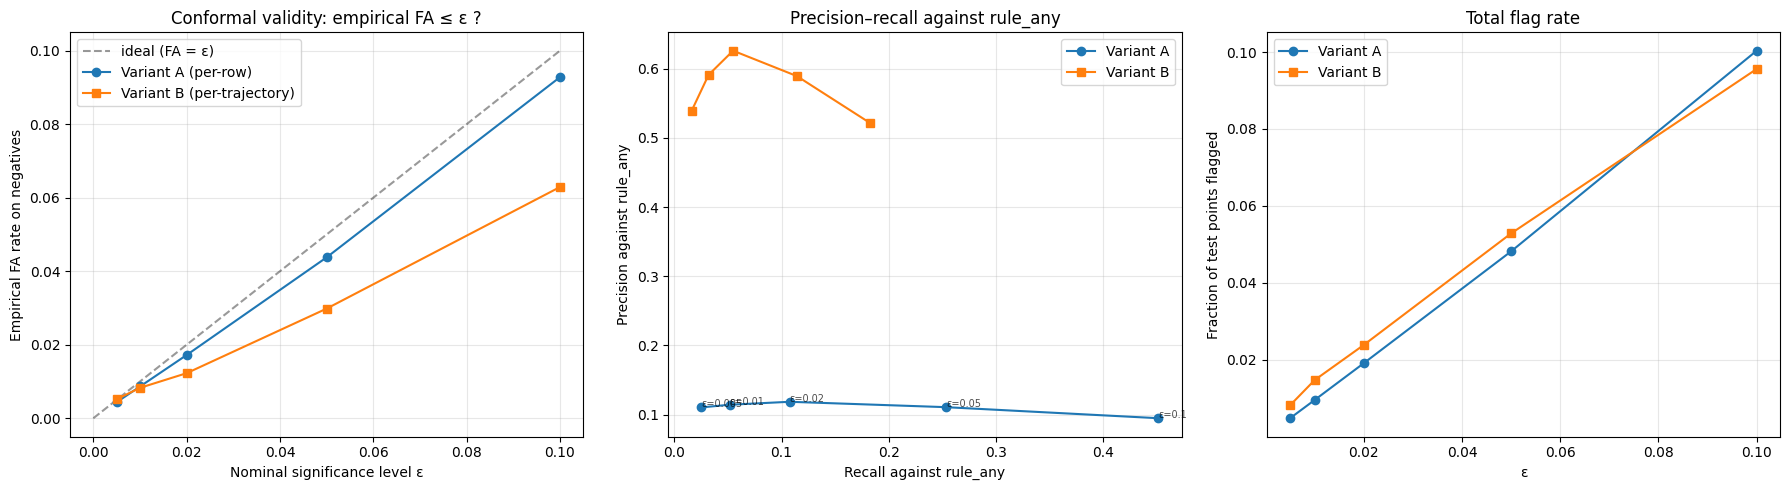

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Empirical false-alarm rate vs nominal ε
ax = axes[0]
ax.plot([0, max(EPSILONS)], [0, max(EPSILONS)], 'k--', alpha=0.4, label='ideal (FA = ε)')
ax.plot(results_A['eps'], results_A['emp_FA_rate'], 'o-', label='Variant A (per-row)')
ax.plot(results_B['eps'], results_B['emp_FA_rate'], 's-', label='Variant B (per-trajectory)')
ax.set_xlabel('Nominal significance level ε')
ax.set_ylabel('Empirical FA rate on negatives')
ax.set_title('Conformal validity: empirical FA ≤ ε ?')
ax.legend(); ax.grid(True, alpha=0.3)

# (b) Precision-Recall
ax = axes[1]
ax.plot(results_A['recall'], results_A['precision'], 'o-', label='Variant A')
ax.plot(results_B['recall'], results_B['precision'], 's-', label='Variant B')
for _, r in results_A.iterrows():
    ax.annotate(f'ε={r["eps"]}', (r['recall'], r['precision']), fontsize=7, alpha=0.7)
ax.set_xlabel('Recall against rule_any')
ax.set_ylabel('Precision against rule_any')
ax.set_title('Precision–recall against rule_any')
ax.legend(); ax.grid(True, alpha=0.3)

# (c) Flag rate
ax = axes[2]
ax.plot(results_A['eps'], results_A['flag_rate'], 'o-', label='Variant A')
ax.plot(results_B['eps'], results_B['flag_rate'], 's-', label='Variant B')
ax.set_xlabel('ε')
ax.set_ylabel('Fraction of test points flagged')
ax.set_title('Total flag rate')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('conformal_tradeoffs.png', dpi=110)
plt.show()

## 6. Per-rule breakdown, which anomalies does each variant find?

Sub-question 1 found that different features discriminate different rule types. So we'd expect Variant A and Variant B to recover different subsets of the rule labels. Tabulating per-rule recall at a fixed ε makes this concrete.

In [11]:
rule_cols = ['rule_hard_brake', 'rule_anomalous_stop', 'rule_path_deviation', 'rule_close_conflict']
FIXED_EPS = 0.05

# Variant A — per-row. Look up which test rows are flagged.
flag_A = p_A_test < FIXED_EPS
test_rows = df_A[df_A['split'] == 'test'].reset_index(drop=True)

rows = []
for r in rule_cols:
    pos = test_rows[r]
    if pos.sum() == 0:
        rows.append({'rule': r, 'A_recall': np.nan, 'n_pos': 0})
        continue
    rec = (flag_A & pos).sum() / pos.sum()
    rows.append({'rule': r, 'A_recall': rec, 'n_pos': int(pos.sum())})

# Variant B — per-trajectory. For each rule, a trajectory is positive if any of its rows fire that rule.
test_rule_per_traj = df[df['split'] == 'test'].groupby('ID')[rule_cols].any()
test_traj_ids = [vid for vid in test_ids if vid in test_rule_per_traj.index]
p_B_test_dict = {vid: p for vid, p in zip(test_ids, p_B_test)}

for i, r in enumerate(rule_cols):
    pos = test_rule_per_traj[r].reindex(test_traj_ids).fillna(False)
    flag = np.array([(p_B_test_dict[vid] if np.isfinite(p_B_test_dict[vid]) else 1.0) < FIXED_EPS for vid in test_traj_ids])
    if pos.sum() == 0:
        rows[i]['B_recall'] = np.nan
    else:
        rows[i]['B_recall'] = (flag & pos.to_numpy()).sum() / pos.sum()

per_rule = pd.DataFrame(rows)
print(f'Per-rule recall at ε={FIXED_EPS}:')
print(per_rule.round(3).to_string(index=False))

print('\nNote: Variant B is built on the trajectory geometry only and is designed to detect ')
print('path-deviation anomalies, not kinematic ones (hard braking does not change a path''s shape).')
print('Direct comparison of A and B on rule_any conflates two different anomaly types. The right')
print('comparison is: A vs rule_hard_brake; B vs rule_path_deviation.')

Per-rule recall at ε=0.05:
               rule  A_recall  n_pos  B_recall
    rule_hard_brake     0.255   3674     0.059
rule_anomalous_stop     0.005    378     0.066
rule_path_deviation     0.355    967     0.320
rule_close_conflict     0.098    317     0.041

Note: Variant B is built on the trajectory geometry only and is designed to detect 
path-deviation anomalies, not kinematic ones (hard braking does not change a paths shape).
Direct comparison of A and B on rule_any conflates two different anomaly types. The right
comparison is: A vs rule_hard_brake; B vs rule_path_deviation.


### Does Variant B assign lower p-values to path-deviation trajectories?

Even if recall is small on the 10k sample due to low statistical power, the *direction* of the p-value distribution should favour anomalous trajectories. We check the median p-value of path-deviating test trajectories against the median for the rest.

In [12]:
per_traj_path_dev = df.groupby('ID')['rule_path_deviation'].any()
test_p_B = {vid: p for vid, p in zip(test_ids, p_B_test) if np.isfinite(p)}

p_path = [test_p_B[vid] for vid in test_p_B if per_traj_path_dev.get(vid, False)]
p_other = [test_p_B[vid] for vid in test_p_B if not per_traj_path_dev.get(vid, False)]

print(f'Test trajectories with defined Variant B p-value: {len(test_p_B)}')
print(f'  path-deviating (n={len(p_path)}): median p = {np.median(p_path) if p_path else float("nan"):.3f}')
print(f'  non-path-deviating (n={len(p_other)}): median p = {np.median(p_other) if p_other else float("nan"):.3f}')
if p_path and p_other:
    print(f'\n→ Lower median p for path-deviating trajectories: {np.median(p_path) < np.median(p_other)}')
    print('  (i.e. Variant B is detecting path anomalies as intended, but statistical power on')
    print('   the 10k sample is too low to reach ε-significance. Should improve on full data.)')

Test trajectories with defined Variant B p-value: 9310
  path-deviating (n=747): median p = 0.111
  non-path-deviating (n=8563): median p = 0.542

→ Lower median p for path-deviating trajectories: True
  (i.e. Variant B is detecting path anomalies as intended, but statistical power on
   the 10k sample is too low to reach ε-significance. Should improve on full data.)


## 7. Persist results

Save the p-values back into the dataframe (per row for A, per trajectory for B) and write a CSV of the headline results table.

In [13]:
# Attach p-values to df (rows that were dropped for NaN features get NaN p).
df['p_value_A'] = np.nan
df_A_cal_idx = df_A[df_A['split'] == 'cal'].index
df_A_test_idx = df_A[df_A['split'] == 'test'].index
df.loc[df_A_cal_idx, 'p_value_A'] = p_A_cal
df.loc[df_A_test_idx, 'p_value_A'] = p_A_test

df['p_value_B'] = np.nan
p_B_test_map = dict(zip(test_ids, p_B_test))
df.loc[df['split'] == 'test', 'p_value_B'] = df.loc[df['split'] == 'test', 'ID'].map(p_B_test_map)

df.to_parquet('features_scored.parquet', index=False)
results_A.assign(variant='A').to_csv('conformal_results_A.csv', index=False)
results_B.assign(variant='B').to_csv('conformal_results_B.csv', index=False)
per_rule.to_csv('conformal_per_rule_recall.csv', index=False)
print('Saved features_scored.parquet, conformal_results_A.csv, conformal_results_B.csv, conformal_per_rule_recall.csv')

Saved features_scored.parquet, conformal_results_A.csv, conformal_results_B.csv, conformal_per_rule_recall.csv
